## Lab 1 - Electricity Consumption Forecast with ANN

### 0. Imports

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
import matplotlib.pyplot as plt

In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [6]:
from sklearn.metrics import mean_squared_error as mse 
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae

Source files:
- `electricity_train.csv` - train set (2011-2013)
- `electricity_test.csv` - test set (2014)
features/target - timestamp (15 min), consumption

### 0.0. Check the sets

In [7]:
# go back to root path
BASE_DIR = Path.cwd().parent
data_path = BASE_DIR / "data"

# read csv
train_df = pd.read_csv(data_path / "electricity_train.csv")
test_df = pd.read_csv(data_path / "electricity_test.csv")

### 0.1. Small EDA

In [8]:
print(f"Train df columns: {train_df.columns}")
print(f"Test df columns: {test_df.columns}")
print(f"Train df shape: {train_df.shape}")
print(f"Test df shape: {test_df.shape}")

Train df columns: Index(['timestamp', 'consumption'], dtype='str')
Test df columns: Index(['timestamp', 'consumption'], dtype='str')
Train df shape: (105215, 2)
Test df shape: (35040, 2)


In [9]:
pd.concat(
    [train_df.head(10), test_df.head(10)],
    axis=1,
    keys=["train_df.head", "test_df.head"]
)

train_df.head                     test_df.head            
             timestamp consumption            timestamp consumption
0  2011-01-01 00:15:00   -0.704319  2014-01-01 00:00:00   -0.932595
1  2011-01-01 00:30:00   -0.704319  2014-01-01 00:15:00   -0.957931
2  2011-01-01 00:45:00   -0.678983  2014-01-01 00:30:00   -0.932595
3  2011-01-01 01:00:00   -0.653647  2014-01-01 00:45:00   -0.907259
4  2011-01-01 01:15:00   -0.704319  2014-01-01 01:00:00   -0.881923
5  2011-01-01 01:30:00   -0.704319  2014-01-01 01:15:00   -0.932595
6  2011-01-01 01:45:00   -0.729908  2014-01-01 01:30:00   -0.932595
7  2011-01-01 02:00:00   -0.704319  2014-01-01 01:45:00   -0.932595
8  2011-01-01 02:15:00   -0.704319  2014-01-01 02:00:00   -0.932595
9  2011-01-01 02:30:00   -0.678983  2014-01-01 02:15:00   -0.932595

In [10]:
# Check for Nans
print(f"Train df - number of Nan values: {train_df.isna().sum()}")
print(f"Test df - number of Nan values: {test_df.isna().sum()}")


Train df - number of Nan values: timestamp      0
consumption    0
dtype: int64
Test df - number of Nan values: timestamp      0
consumption    0
dtype: int64


In [11]:
# Check if timestamp is sorted
print("Train_df - the timestamp feature is sorted and increasing" if train_df["timestamp"].is_monotonic_increasing else "SORT timestamp!!")
print("Test_df - the timestamp feature is sorted and increasing" if test_df["timestamp"].is_monotonic_increasing else "SORT timestamp!!")

Train_df - the timestamp feature is sorted and increasing
Test_df - the timestamp feature is sorted and increasing


In [12]:
# Check basic stats
pd.concat(
    [train_df.describe(), test_df.describe()],
    axis=1,
    keys=["train", "test"]
)

,train,test
,consumption,consumption
count,105215.000000,35040.000000
mean,-0.007469,0.022430
std,1.056835,0.805208
min,-1.414483,-1.414483
25%,-0.957931,-0.729908
50%,-0.349363,-0.095751
75%,0.797593,0.695742
max,3.028924,2.645845


In [13]:
# check if timestamp has duplicates
print("Train_df - NO timestamp duplicates" if train_df["timestamp"].duplicated().sum()==0 else "Train_df DUPLICATES!!")
print("Test_df - NO timestamp duplicates" if test_df["timestamp"].duplicated().sum()==0 else "Test_df DUPLICATES!!")

Train_df - NO timestamp duplicates
Test_df - NO timestamp duplicates


In [14]:
# check outliers func
def check_outliers(df: pd.DataFrame, column: str) -> pd.DataFrame:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3-q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

In [15]:
# check outliers for both sets
pd.concat(
    [check_outliers(train_df, 'consumption'), check_outliers(test_df, 'consumption')], 
    axis=1, 
    keys=["train_df", "test_df"]
    )

Empty DataFrame
Columns: [(train_df, timestamp), (train_df, consumption), (test_df, timestamp), (test_df, consumption)]
Index: []

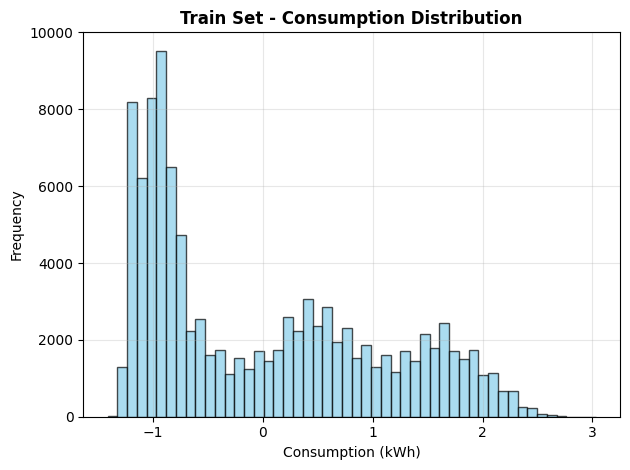

In [16]:
fig = plt.plot(figsize=(14, 5))

# Train distribution
plt.hist(train_df['consumption'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Train Set - Consumption Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Consumption (kWh)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# here I stop checking test set because we are pretending we dont have it

### outcomes of EDA:
- datasets are clean, normalized, basically we don't need to do any feature engineering
- for this sets I would split timestamp to date, month, season etc but I feel like for this task it will make life harder because we want to use linear layers in NN

### Task Q1 - Create a Neural Network with 1 Linear Layer 
-  We begin with a minimal regression model that 
uses the last W steps to predict the next step.   Note, Build an MLP with a single Linear layer that takes a flattened window and predicts the next 15 -minute value.

### Shared training set up (for later):
- configs
- windows
- sets split
- tensors and loaders

In [17]:
# configs (shared)
W = 288     # 72 h with 15-min frequency
BATCH_SIZE = 256
EPOCHS = 20
LR = 1e-4

In [18]:
# sliding windows (shared)
def make_windows(values: np.ndarray, window: int):
    X, y = [], []
    for i in range(len(values) - window):
        X.append(values[i:i + window])
        y.append(values[i + window])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

In [19]:
target_series = train_df["consumption"].to_numpy(dtype=np.float32)

In [20]:
X_all, y_all = make_windows(target_series, W)

In [21]:
split_idx = int(0.8 * len(X_all))
X_train, X_val = X_all[:split_idx], X_all[split_idx:]
y_train, y_val = y_all[:split_idx], y_all[split_idx:]

In [22]:
# dataloaders
train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train).unsqueeze(1)
)
val_ds = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val).unsqueeze(1)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


In [33]:
# model for Q1 itself
model = nn.Linear(W, 1)
print(model)

Linear(in_features=288, out_features=1, bias=True)


In [24]:
# prediction
xb_sample = torch.from_numpy(X_train[:4])
print(f"input: {xb_sample.shape} → output: {model(xb_sample).shape}")


input: torch.Size([4, 288]) → output: torch.Size([4, 1])


### Q2 - Add Two Hidden Layers  
- Increase capacity with hidden layers to capture non -linear relationships.
Note, extend the model to two hidden layers. No activations yet.

In [26]:
# Q2 model: two hidden linear layers (no activations)
class TwoHiddenLinear(nn.Module):
    def __init__(self, in_features: int, h1: int = 128, h2: int = 64, out_features: int = 1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

q2_model = TwoHiddenLinear(in_features=W, h1=128, h2=64, out_features=1)

In [27]:
# check for shape (we are not training yet)
print(f"input: {xb_sample.shape} → output: {q2_model(xb_sample).shape}")

input: torch.Size([4, 288]) → output: torch.Size([4, 1])


### Q3. Add Activation Function   -  Non‑linear activations increase expressive power.   
Note, Insert ReLU after each hidden layer.  


In [29]:
# Q3 model: relu addition
class TwoHiddenLinearWithRelu(nn.Module):
    def __init__(self, in_features: int, h1: int = 128, h2: int = 64, out_features: int = 1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, out_features)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

q3_model = TwoHiddenLinearWithRelu(in_features=W, h1=128, h2=64, out_features=1)

In [32]:
# check for shape (we are not training yet)
print(q3_model)

TwoHiddenLinearWithRelu(
  (fc1): Linear(in_features=288, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


### Q4. Forward Pass Regression (Loss & One Step)   -  We want a scalar training objective to minimize prediction error.   
Note,  Use MSELoss and verify the forward/backward path on a single batch.  

In [34]:
# check forward + backward on 1 batch
xb, yb = next(iter(train_loader))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(q3_model.parameters(), lr=LR)

# forward pass 
preds = q3_model(xb)
loss = criterion(preds, yb)

# backward pass
optimizer.zero_grad()
loss.backward()
optimizer.step() #only 1 weight update

print(f"preds shape: {preds.shape}")
print(f"batch loss: {loss.item()}")
print(f"grad exist: {q3_model.fc1.weight.grad}")

preds shape: torch.Size([256, 1])
batch loss: 1.3735495805740356
grad exist: tensor([[-4.4956e-05,  1.5191e-04,  3.3301e-04,  ..., -3.3880e-02,
         -3.5388e-02, -3.6969e-02],
        [ 6.2528e-03,  6.9818e-03,  8.1742e-03,  ..., -4.7399e-02,
         -5.0326e-02, -5.3867e-02],
        [-9.3496e-03, -9.2759e-03, -9.1287e-03,  ...,  9.5834e-03,
          1.0242e-02,  1.1011e-02],
        ...,
        [ 5.2245e-03,  5.2716e-03,  5.3433e-03,  ..., -1.0318e-02,
         -1.0894e-02, -1.1799e-02],
        [-4.9237e-03, -4.9206e-03, -4.9491e-03,  ...,  1.7454e-03,
          1.6439e-03,  1.5856e-03],
        [-2.1931e-03, -2.3669e-03, -2.8487e-03,  ...,  1.7494e-02,
          1.8871e-02,  2.0051e-02]])


### Q5.  Train the Neural Network   -  Fit the model on training windows for several epochs.
Note,  Train for 5 epochs and record average train loss per epoch. 

In [35]:
train_losses = []

for epoch in range(5):
    q3_model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = q3_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss/len(train_ds)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/5 - train MSE: {avg_loss:.5f}")

Epoch 1/5 - train MSE: 0.39995
Epoch 2/5 - train MSE: 0.12626
Epoch 3/5 - train MSE: 0.08510
Epoch 4/5 - train MSE: 0.06697
Epoch 5/5 - train MSE: 0.05716


Here we checked training on 5 epochs for the q3 model, no validation yet

### Q6. Evaluate the Neural Network   -  We need simple, interpretable metrics.   
Note, Compute MAE, RMSE, MAPE on the test windows (horizon=1).  

In [36]:
test_series = test_df["consumption"].to_numpy(dtype=np.float32)
X_test, y_test = make_windows(test_series, W)

q3_model.eval()
with torch.no_grad():
    y_test_pred = q3_model(torch.from_numpy(X_test)).squeeze(1).numpy()

rmse_q6 = mse(y_test, y_test_pred) ** 0.5
mae_q6  = mae(y_test, y_test_pred)
mape_q6 = mape(y_test, y_test_pred)

print("Q6 - Test Metrics (horizon=1)")
print(f"RMSE : {rmse_q6:.4f}")
print(f"MAE  : {mae_q6:.4f}")
print(f"MAPE : {mape_q6:.4f}")

Q6 - Test Metrics (horizon=1)
RMSE : 0.2520
MAE  : 0.1736
MAPE : 1.1228


### Q7. Hyperparameter Tuning (Tiny Grid) - Even small grids find better trade‑offs of width/learning rate/batch size.   
Run a tiny grid over hidden1 ∈  {64,128}, hidden2 ∈  {32,64}, lr ∈  {1e -3, 3e -4}, batch 
∈  {256,512}; train 3 epochs each; keep the best MAE on test. 

In [37]:
# hyperparametets on grid search
from itertools import product

tiny_grid = {
    "h1": [64, 128],
    "h2": [32, 64],
    "lr": [1e-3, 3e-4],
    "batch": [256, 512],
}

best_mae = float("inf")
best_cfg = None

X_test_t = torch.from_numpy(X_test)

for h1, h2, lr_g, batch_g in product(*tiny_grid.values()):
    # new model for this grid config
    m = TwoHiddenLinearWithRelu(in_features=W, h1=h1, h2=h2)
    opt = torch.optim.Adam(m.parameters(), lr=lr_g)
    crit = nn.MSELoss()

    ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).unsqueeze(1))
    loader = DataLoader(ds, batch_size=batch_g, shuffle=False)

    m.train()
    for _ in range(3):
        for xb, yb in loader:
            opt.zero_grad()
            crit(m(xb), yb).backward()
            opt.step()

    # evaluate MAE on test
    m.eval()
    with torch.no_grad():
        preds = m(X_test_t).squeeze(1).numpy()
    mae_g = mae(y_test, preds)

    print(f"h1={h1:3d} h2={h2:2d} lr={lr_g:.0e} batch={batch_g} -> MAE={mae_g:.4f}")

    if mae_g < best_mae:
        best_mae = mae_g
        best_cfg = {"h1": h1, "h2": h2, "lr": lr_g, "batch": batch_g}

print(f"\nBest config: {best_cfg} -> MAE={best_mae:.4f}")

h1= 64 h2=32 lr=1e-03 batch=256 -> MAE=0.1476
h1= 64 h2=32 lr=1e-03 batch=512 -> MAE=0.1619
h1= 64 h2=32 lr=3e-04 batch=256 -> MAE=0.1720
h1= 64 h2=32 lr=3e-04 batch=512 -> MAE=0.2053
h1= 64 h2=64 lr=1e-03 batch=256 -> MAE=0.1497
h1= 64 h2=64 lr=1e-03 batch=512 -> MAE=0.1618
h1= 64 h2=64 lr=3e-04 batch=256 -> MAE=0.1641
h1= 64 h2=64 lr=3e-04 batch=512 -> MAE=0.1908
h1=128 h2=32 lr=1e-03 batch=256 -> MAE=0.1417
h1=128 h2=32 lr=1e-03 batch=512 -> MAE=0.1565
h1=128 h2=32 lr=3e-04 batch=256 -> MAE=0.1671
h1=128 h2=32 lr=3e-04 batch=512 -> MAE=0.1821
h1=128 h2=64 lr=1e-03 batch=256 -> MAE=0.1432
h1=128 h2=64 lr=1e-03 batch=512 -> MAE=0.1561
h1=128 h2=64 lr=3e-04 batch=256 -> MAE=0.1547
h1=128 h2=64 lr=3e-04 batch=512 -> MAE=0.1792

Best config: {'h1': 128, 'h2': 32, 'lr': 0.001, 'batch': 256} -> MAE=0.1417


### Q8. Plot Actual vs. Predicted on the Test Set (2014)   -  Before deploying a forecaster, teams always generate a visual sanity check of predictions against the held -out test year.   
Note, Plot Actual vs.Predicted for the 2014 test period at 
(a) 15 -minute resolution for a single week and 
(b) hourly resolution for the full year.

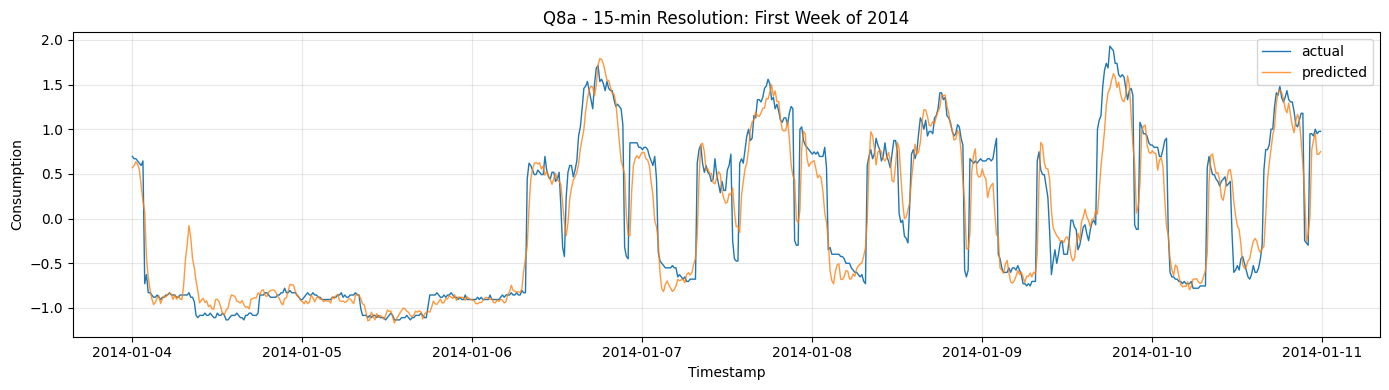

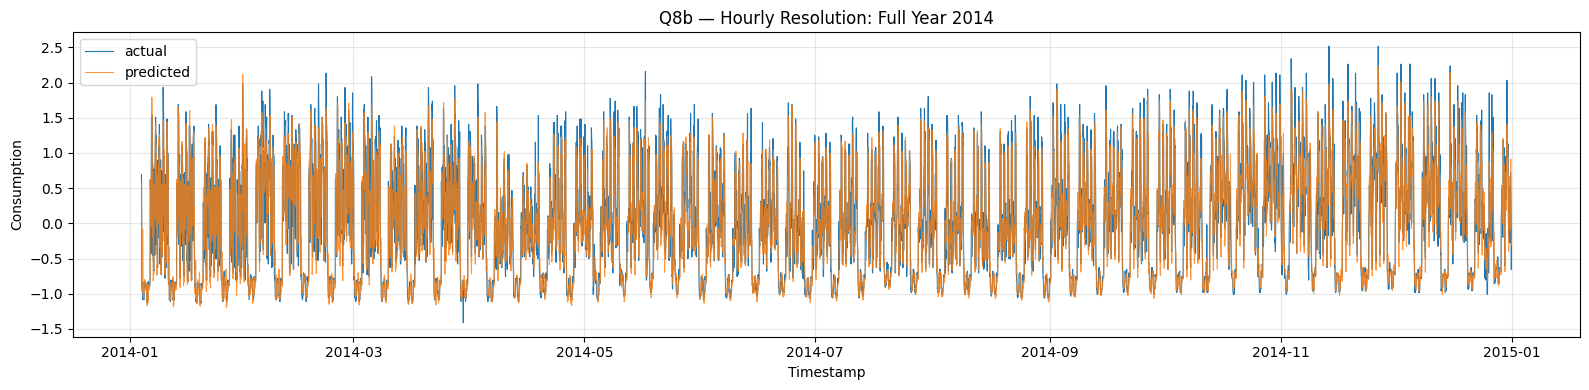

In [38]:
timestamps = pd.to_datetime(test_df["timestamp"].iloc[W:].values)

# (a) 15-min resolution - first week (7 days × 24h × 4 = 672 points)
one_week = 7 * 24 * 4
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timestamps[:one_week], y_test[:one_week], label="actual", linewidth=1)
ax.plot(timestamps[:one_week], y_test_pred[:one_week], label="predicted", linewidth=1, alpha=0.8)
ax.set_title("Q8a - 15-min Resolution: First Week of 2014")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (b) hourly resolution — full year (it was 15 min, now 60 min soo every 4th point)
actual_hourly = y_test[::4]
pred_hourly = y_test_pred[::4]
ts_hourly = timestamps[::4]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(ts_hourly, actual_hourly, label="actual", linewidth=0.8)
ax.plot(ts_hourly, pred_hourly,   label="predicted", linewidth=0.8, alpha=0.8)
ax.set_title("Q8b — Hourly Resolution: Full Year 2014")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Q9. Provide Forecast for the Next 12 Months  - Deliver a full‑year forecast (the entire 201 5) at 15‑minute granularity, using recursive one‑step predictions.   
Note, Use your best tuned model to roll forward across the whole test horizon and produce a 12‑month forecast series.   

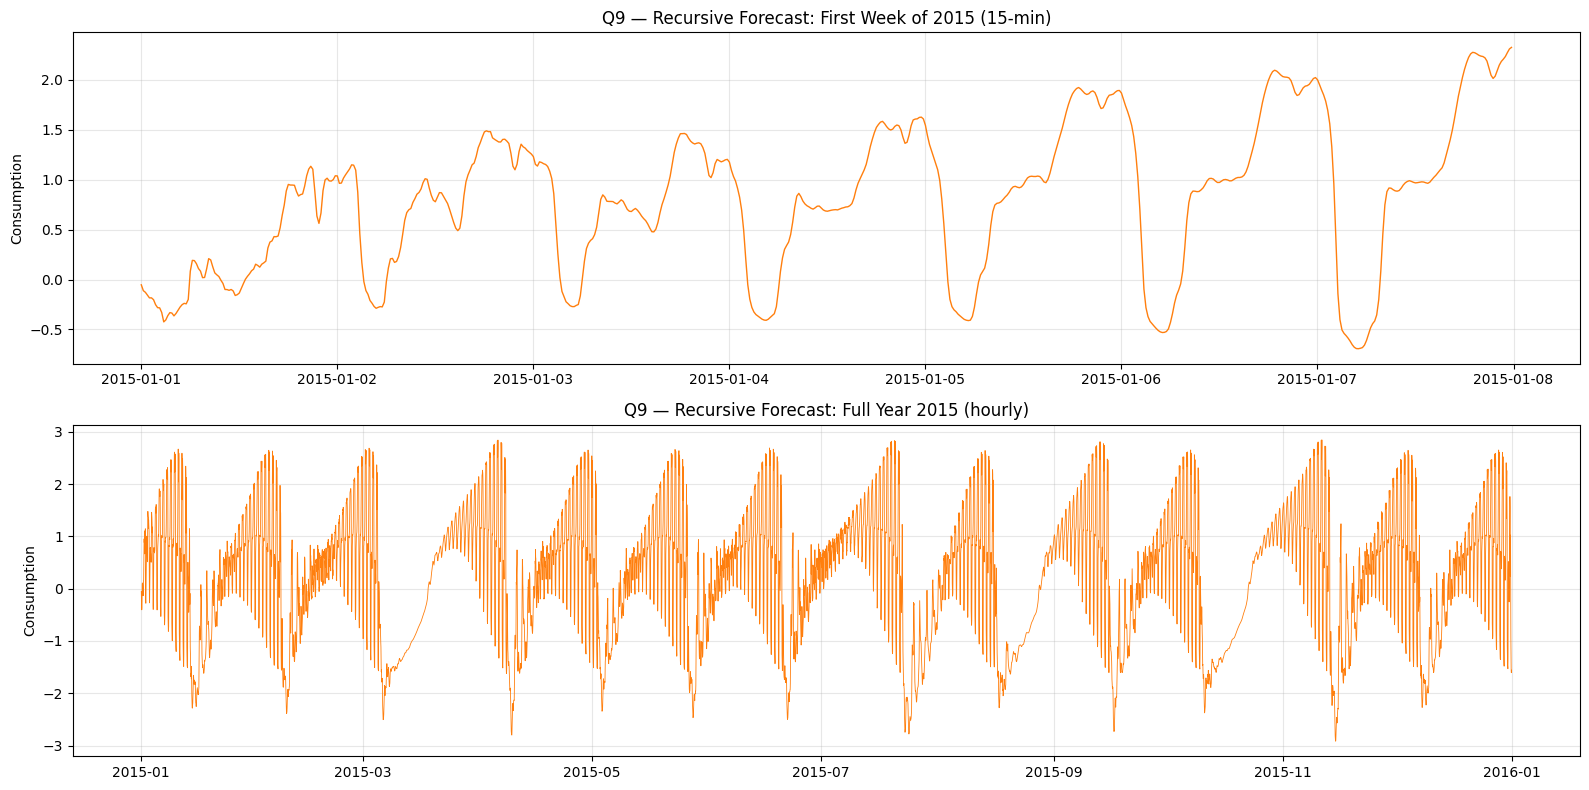

Forecast steps: 35040 (365 days)


In [39]:
# rettrain best model
best_model = TwoHiddenLinearWithRelu(
    in_features=W, h1=best_cfg["h1"], h2=best_cfg["h2"]
)
best_opt = torch.optim.Adam(best_model.parameters(), lr=best_cfg["lr"])
best_crit = nn.MSELoss()
best_ds = TensorDataset(
    torch.from_numpy(X_train), torch.from_numpy(y_train).unsqueeze(1)
)
best_loader = DataLoader(best_ds, batch_size=best_cfg["batch"], shuffle=False)

best_model.train()
for _ in range(5):
    for xb, yb in best_loader:
        best_opt.zero_grad()
        best_crit(best_model(xb), yb).backward()
        best_opt.step()

# recursive forecast - seed with last W values of 2014
seed = test_series[-W:].tolist()
n_steps = 365 * 24 * 4

forecast = []
best_model.eval()
with torch.no_grad():
    buffer = seed.copy()
    for _ in range(n_steps):
        x = torch.tensor(buffer[-W:], dtype=torch.float32).unsqueeze(0)
        pred = best_model(x).item()
        forecast.append(pred)
        buffer.append(pred)

# 2015 timestamps
ts_2015 = pd.date_range(start="2015-01-01", periods=n_steps, freq="15min")

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# first week
axes[0].plot(ts_2015[:7*24*4], forecast[:7*24*4], linewidth=1, color="tab:orange")
axes[0].set_title("Q9 — Recursive Forecast: First Week of 2015 (15-min)")
axes[0].set_ylabel("Consumption")
axes[0].grid(alpha=0.3)

# full year hourly
axes[1].plot(ts_2015[::4], forecast[::4], linewidth=0.6, color="tab:orange")
axes[1].set_title("Q9 — Recursive Forecast: Full Year 2015 (hourly)")
axes[1].set_ylabel("Consumption")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Forecast steps: {len(forecast)} ({len(forecast)/(4*24):.0f} days)")

In [40]:
forecast

[-0.05237993597984314,
 -0.11098171770572662,
 -0.12741215527057648,
 -0.1549433320760727,
 -0.1833859533071518,
 -0.1831618696451187,
 -0.20147012174129486,
 -0.2515430450439453,
 -0.28131067752838135,
 -0.28315913677215576,
 -0.3294553756713867,
 -0.42392289638519287,
 -0.4040513038635254,
 -0.36080777645111084,
 -0.33096927404403687,
 -0.33563512563705444,
 -0.3637533187866211,
 -0.33948105573654175,
 -0.30734825134277344,
 -0.27528196573257446,
 -0.2512573003768921,
 -0.23805539309978485,
 -0.2429044097661972,
 -0.19892512261867523,
 0.08398301899433136,
 0.19250358641147614,
 0.19014295935630798,
 0.1593206375837326,
 0.11071270704269409,
 0.08427686989307404,
 0.019395962357521057,
 0.0212545245885849,
 0.10686904191970825,
 0.20970848202705383,
 0.19669514894485474,
 0.1277291625738144,
 0.06721367686986923,
 0.04747873544692993,
 0.030403390526771545,
 -0.006814584136009216,
 -0.03881749510765076,
 -0.09926481544971466,
 -0.10001133382320404,
 -0.10776369273662567,
 -0.09903639

### Q10. Plot the Forecast of 2015 (Out‑of‑Sample Roll‑Forward)  - Planners often need a next‑year forecast even when no ground truth is available yet.  
Note, Using your trained model, generate a synthetic forecast for 2015 by recursive one -step predictions . 

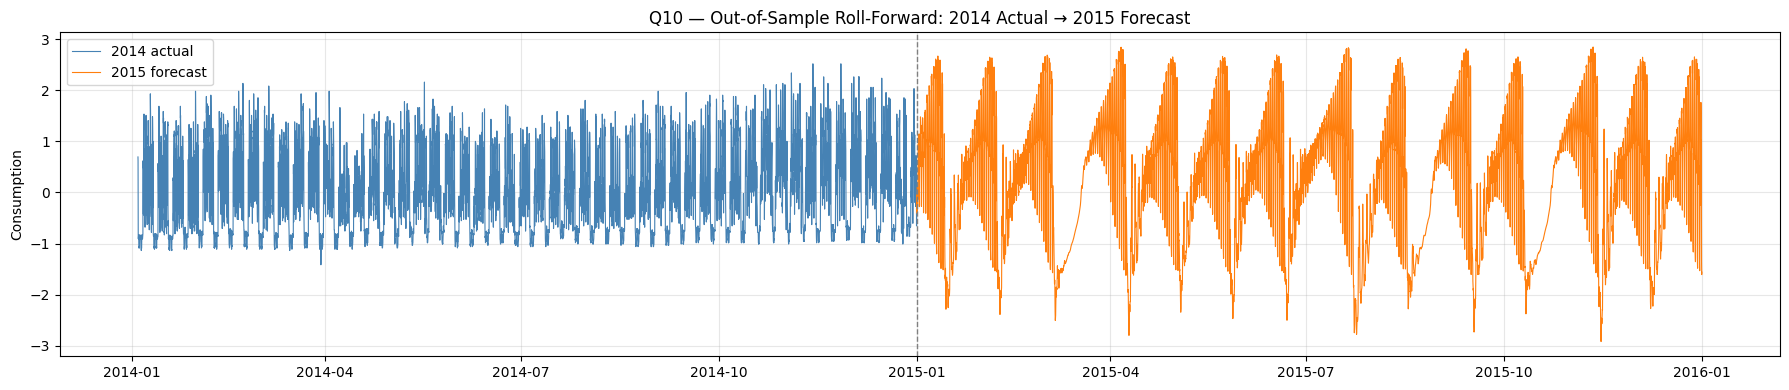

In [41]:
# it was already plotted in the prev cell (together with Q9)
# somme addition
ts_2014 = pd.to_datetime(test_df["timestamp"].iloc[W:].values)[::4]
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(ts_2014, y_test[::4], label="2014 actual", linewidth=0.8, color="steelblue")
ax.plot(ts_2015[::4], forecast[::4], label="2015 forecast", linewidth=0.8, color="tab:orange")
ax.axvline(pd.Timestamp("2015-01-01"), color="gray", linestyle="--", linewidth=1)
ax.set_title("Q10 — Out-of-Sample Roll-Forward: 2014 Actual → 2015 Forecast")
ax.set_ylabel("Consumption")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ADDITIONAL -best model (best config obtained by grid search, all the hidden and relu), criterion, optim and validation (it was absent before)

In [42]:
best_model_final = TwoHiddenLinearWithRelu(
    in_features=W, h1=best_cfg["h1"], h2=best_cfg["h2"]
)
best_criterion = nn.MSELoss()
best_optimizer = torch.optim.Adam(best_model_final.parameters(), lr=best_cfg["lr"])

best_loader_final = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).unsqueeze(1)),
    batch_size=best_cfg["batch"], shuffle=False
)

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    best_model_final.train()
    running_train = 0.0
    for xb, yb in best_loader_final:
        best_optimizer.zero_grad()
        preds = best_model_final(xb)
        loss = best_criterion(preds, yb)
        loss.backward()
        best_optimizer.step()
        running_train += loss.item() * xb.size(0)

    train_epoch_loss = running_train / len(train_ds)
    train_losses.append(train_epoch_loss)

    best_model_final.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = best_model_final(xb)
            loss = best_criterion(preds, yb)
            running_val += loss.item() * xb.size(0)

    val_epoch_loss = running_val / len(val_ds)
    val_losses.append(val_epoch_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} - train MSE: {train_epoch_loss:.5f}, val MSE: {val_epoch_loss:.5f}")


Epoch 01/20 - train MSE: 0.13801, val MSE: 0.08749
Epoch 05/20 - train MSE: 0.03688, val MSE: 0.05009
Epoch 10/20 - train MSE: 0.03104, val MSE: 0.04458
Epoch 15/20 - train MSE: 0.02847, val MSE: 0.04331
Epoch 20/20 - train MSE: 0.02650, val MSE: 0.04471


In [45]:
# metrics on val and test
best_model_final.eval()
with torch.no_grad():
    y_val_pred_best  = best_model_final(torch.from_numpy(X_val)).squeeze(1).numpy()
    y_test_pred_best = best_model_final(torch.from_numpy(X_test)).squeeze(1).numpy()

print("Val - RMSE:", (mse(y_val,  y_val_pred_best)  ** 0.5), "; MAE:", mae(y_val,  y_val_pred_best))
print("Test - RMSE:", (mse(y_test, y_test_pred_best) ** 0.5), "; MAE:", mae(y_test, y_test_pred_best))
print("Val - MAPE:", (mape(y_val,  y_val_pred_best)))
print("Test - MAPE", (mape(y_test,  y_test_pred_best)))

Val - RMSE: 0.21143656432248933 ; MAE: 0.12557917833328247
Test - RMSE: 0.19415429026905417 ; MAE: 0.12288148701190948
Val - MAPE: 0.4667925536632538
Test - MAPE 0.7365434169769287


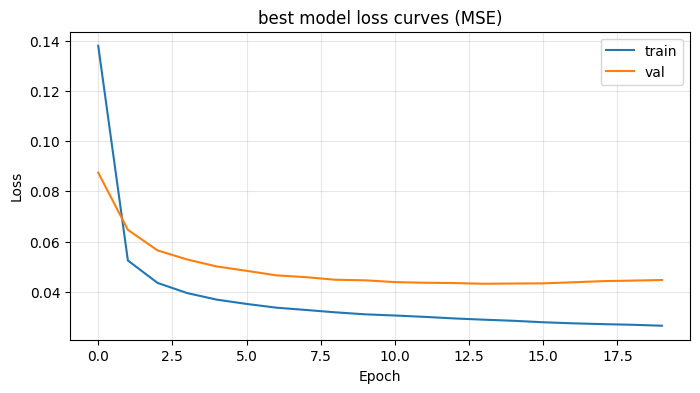

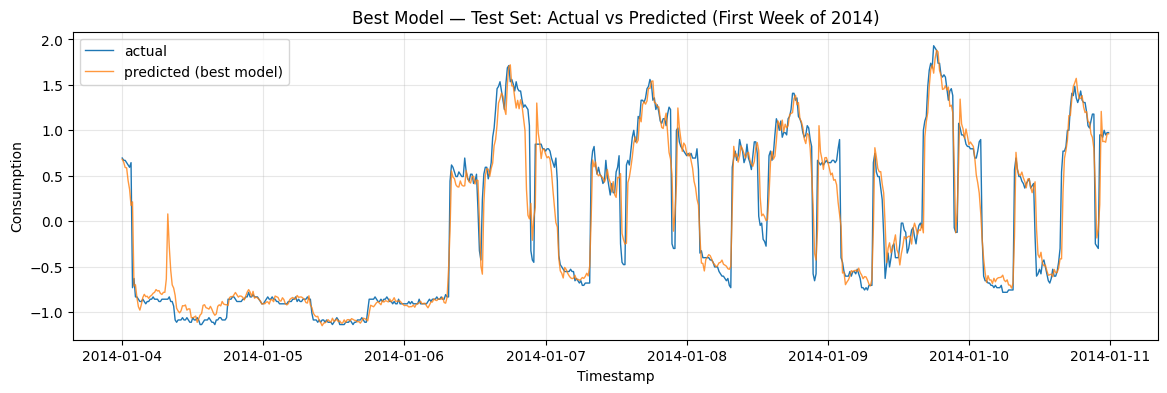

In [47]:
# Plot losses
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("best model loss curves (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Plot test set: actual vs predicted, first week of 2014
one_week = 7 * 24 * 4  # 672 points
test_timestamps = pd.to_datetime(test_df["timestamp"].iloc[W:].values)

plt.figure(figsize=(14, 4))
plt.plot(test_timestamps[:one_week], y_test[:one_week], label="actual", linewidth=1)
plt.plot(test_timestamps[:one_week], y_test_pred_best[:one_week], label="predicted (best model)", linewidth=1, alpha=0.8)
plt.title("Best Model — Test Set: Actual vs Predicted (First Week of 2014)")
plt.xlabel("Timestamp")
plt.ylabel("Consumption")
plt.legend()
plt.grid(alpha=0.3)